/var/folders/f6/wfrnxqf108nbx2nvsph0n70h0000gn/T/ipykernel_3077/1076363678.py:141: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


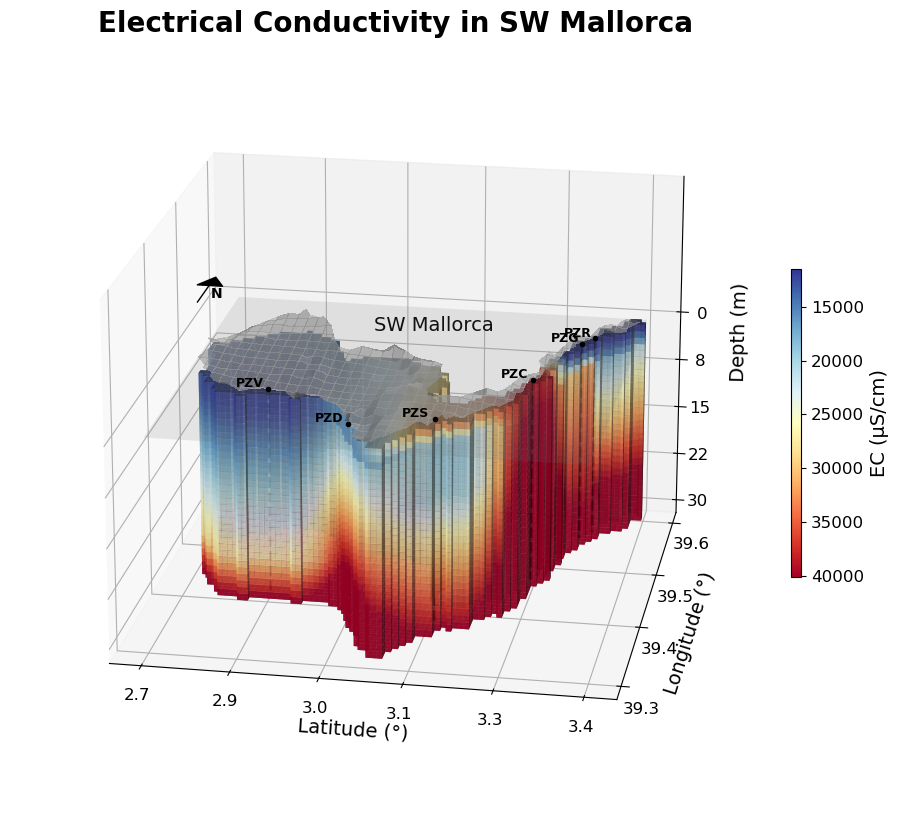

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio as rio
from matplotlib import cm
from shapely import contains_xy
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from pyproj import Transformer  # <-- NUEVO
NX, NZ, V_LIM = 60, 35, (11500, 40000)
DEPTH_TARGETS = np.arange(0, 31, 1)   # 0..30 (31 niveles)
MDT_ZSCALE = -0.02                    # escalado MDT (como antes)
def idw_2d(xy, vals, X, Y, p=3.0, eps=1e-12):
    dx = X.ravel()[:, None] - xy[:, 0]
    dy = Y.ravel()[:, None] - xy[:, 1]
    d = np.sqrt(dx*dx + dy*dy) + eps
    w = 1.0 / (d ** p)
    z = (w @ vals) / w.sum(axis=1)
    return z.reshape(X.shape)
def closest_valid_cell(ix, iy, valid_mask):
    if valid_mask[iy, ix]:
        return ix, iy
    yy, xx = np.argwhere(valid_mask).T
    k = np.argmin((xx - ix)**2 + (yy - iy)**2)
    return int(xx[k]), int(yy[k])
df = pd.read_excel("../datos_M_.xlsx", "3D").dropna(subset=["Well", "x", "y", "Depth_m", "EC"])
df = df.sort_values(["Well", "Depth_m"])
gdf_area = gpd.read_file("../__QGIS/area3.shp").to_crs(epsg=25831)
gdf_pts = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y), crs=4326).to_crs(epsg=25831)
df["E"] = gdf_pts.geometry.x.to_numpy()
df["N"] = gdf_pts.geometry.y.to_numpy()
df["Dpos"] = df["Depth_m"].astype(float)
xmin, ymin, xmax, ymax = gdf_area.total_bounds
nx = 80
ny = int(nx * (ymax - ymin) / (xmax - xmin))
Xg, Yg = np.meshgrid(np.linspace(xmin, xmax, nx),np.linspace(ymin, ymax, ny),indexing="xy")
geom = gdf_area.geometry.union_all()
mask = contains_xy(geom, Xg, Yg)  # (ny,nx)
with rio.open("../__QGIS/mdt_M.tif") as src:
    coords = np.c_[Xg.ravel(), Yg.ravel()]
    S = np.fromiter((v[0] for v in src.sample(coords)), dtype=float, count=coords.shape[0]).reshape(ny, nx)
S = np.where(mask & np.isfinite(S), S, np.nan)
S_norm = S
valid_surface = np.isfinite(S_norm) & mask
well_list = []
for name, g in df.groupby("Well", sort=False):
    d_data = g["Dpos"].to_numpy()
    v_data = g["EC"].to_numpy()
    order = np.argsort(d_data)
    d_data = d_data[order]
    v_data = v_data[order]
    v_interp = np.interp(DEPTH_TARGETS, d_data, v_data, left=v_data[0], right=v_data[-1])
    well_list.append({"name": name,"xy": [g["E"].iloc[0], g["N"].iloc[0]],"vals": v_interp,"dmax": float(d_data.max())})
well_xy = np.array([w["xy"] for w in well_list])           # (n_wells, 2)
well_vals = np.array([w["vals"] for w in well_list])       # (n_wells, 31)
slices = np.empty((len(DEPTH_TARGETS), ny, nx), dtype=float)
for k in range(len(DEPTH_TARGETS)):
    Z = idw_2d(well_xy, well_vals[:, k], Xg, Yg, p=3.0)
    Z[~mask] = np.nan
    slices[k] = Z
cond3d = slices.transpose(2, 1, 0)  # (nx, ny, 31)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")
filled = np.isfinite(cond3d)
norm = plt.Normalize(11500, 40100)
cmap = cm.RdYlBu_r
colors = cmap(norm(np.nan_to_num(cond3d, nan=11500)))
colors[..., 3] = np.where(filled, 0.8, 0.0)
ax.voxels(filled, facecolors=colors, edgecolor="none")
Xsurf, Ysurf = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")
ax.plot_surface(Xsurf, Ysurf, MDT_ZSCALE * S_norm,color=(0.8, 0.8, 0.8, 0.6), zorder=10,edgecolor="none", linewidth=0, antialiased=False, shade=True)
for w in well_list:
    ex, nn = w["xy"]
    ix = int(np.nanargmin(np.abs(Xg[0, :] - ex)))
    iy = int(np.nanargmin(np.abs(Yg[:, 0] - nn)))
    if not np.isfinite(S_norm[iy, ix]):
        yy, xx = np.argwhere(np.isfinite(S_norm)).T
        k = np.argmin((xx - ix)**2 + (yy - iy)**2)
        ix, iy = int(xx[k]), int(yy[k])
    z_top = MDT_ZSCALE * S_norm[iy, ix]
    d_clamped = np.clip(w["dmax"], DEPTH_TARGETS[0], DEPTH_TARGETS[-1])
    iz_bottom = float(np.interp(d_clamped, DEPTH_TARGETS, np.arange(len(DEPTH_TARGETS))))
    ax.plot([ix, ix], [iy, iy], [z_top, iz_bottom], "--", alpha=1, color="k", lw=2)
    ax.plot([ix], [iy], [z_top], ".", color="k", alpha=1, lw=1, zorder=10000000)
    ax.text(ix-6, iy, z_top, str(w["name"]),fontweight="bold",fontsize=9,color="black", zorder=10000000, clip_on=False)
lab = {"text": "SW Mallorca", "x_frac": 0.60, "y_frac": 0.85, "z_off": -4, "ha": "center"}
ix = int(lab["x_frac"] * (nx - 1))
iy = int(lab["y_frac"] * (ny - 1))
ix, iy = closest_valid_cell(ix, iy, valid_surface)
z0 = MDT_ZSCALE * S_norm[iy, ix] + lab["z_off"]
ax.text(ix, iy, z0, lab["text"], ha=lab["ha"], va="bottom", fontsize=14, clip_on=False)
anchor = {"x_frac": 0.08, "y_frac": 0.12, "z": -20, "scale": 3.0}
ix_anchor = anchor["x_frac"] * (nx - 1)
iy_anchor = anchor["y_frac"] * (ny - 1)
iz_top = anchor["z"]
s = anchor["scale"]
p1 = (ix_anchor + s*0.5,  iy_anchor,     iz_top)
p2 = (ix_anchor + s*2.0,  iy_anchor,     iz_top)
p3 = (ix_anchor + s*1.25, iy_anchor + s, iz_top)
ax.add_collection3d(Poly3DCollection([[p1, p2, p3]], edgecolor="k", facecolor="k", linewidths=1))
x_mid = ix_anchor + s*1.25
y_end = iy_anchor - s*2.0
ax.plot([x_mid, x_mid], [iy_anchor, y_end], [iz_top, iz_top], color="k", lw=1)
ax.text(x_mid + s*1.01, y_end + s*0.25, iz_top, "N",color="k", fontsize=10, fontweight="bold",ha="center", va="bottom", clip_on=False)
ax.invert_zaxis()
ax.view_init(elev=20, azim=-80)
ax.set_zlabel("Depth (m)", fontsize=14, labelpad=12)
ax.set_title("Electrical Conductivity in SW Mallorca", fontsize=20, fontweight="bold", pad=-30)
z_ticks = np.linspace(0, len(DEPTH_TARGETS)-1, 5)
ax.set_zticks(z_ticks)
ax.set_zticklabels([f"{d:.0f}" for d in np.linspace(0, DEPTH_TARGETS[-1], 5)], fontsize=12)
transformer = Transformer.from_crs(25831, 4326, always_xy=True)
xticks = np.linspace(0, nx-1, 6).round().astype(int)
yticks = np.linspace(0, ny-1, 4).round().astype(int)
iy_mid = ny // 2
x_e = Xg[iy_mid, xticks]
y_n = Yg[iy_mid, xticks]
lon, lat_dummy = transformer.transform(x_e, y_n)
ix_mid = nx // 2
x_e2 = Xg[yticks, ix_mid]
y_n2 = Yg[yticks, ix_mid]
lon_dummy, lat = transformer.transform(x_e2, y_n2)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{v:.1f}" for v in lon], fontsize=12)
ax.set_xlabel("Latitude (°)", fontsize=14)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{v:.1f}" for v in lat],fontsize=12)
# nivel mar: ax.set_ylabel("Longitude (°)", fontsize=14)ax.plot_surface(Xsurf, Ysurf,np.zeros_like(Xsurf),color=(0.6,0.6,0.6,0.15),edgecolor="none")
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = plt.colorbar(sm, ax=ax, pad=0.01, shrink=0.4, aspect=30)
cbar.set_label("EC (µS/cm)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
cbar.ax.invert_yaxis()
plt.tight_layout()
fig.savefig("7_3D_M.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/f6/wfrnxqf108nbx2nvsph0n70h0000gn/T/ipykernel_3077/3382956278.py:97: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


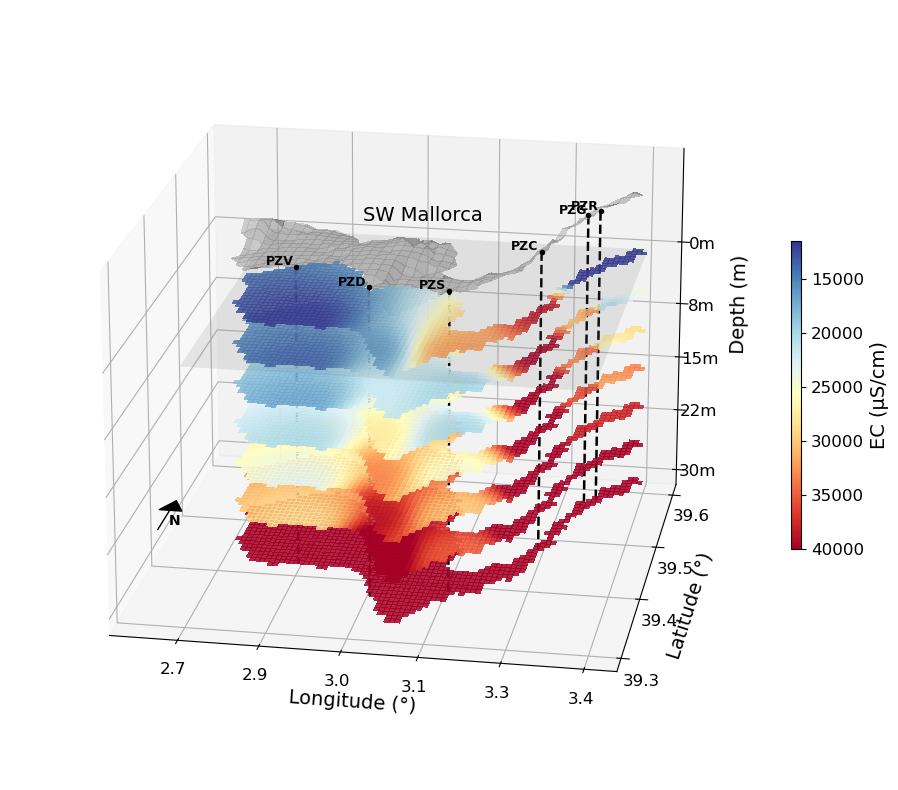

In [ ]:

from matplotlib import cm
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

DEPTHS_TO_PLOT = np.arange(0, 31, 5)   # capas cada 3 m: 0,3,6,...,30
ALPHA_SLICE = 0.85                    # transparencia de cada capa
TOPO_ZSCALE = MDT_ZSCALE              # usas el mismo escalado que ya tenías
TOPO_ZSHIFT = 8.0                     # desplaza MDT hacia arriba para que quede por encima de 0 m

norm = plt.Normalize(V_LIM[0], V_LIM[1])
cmap = cm.RdYlBu_r

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")
Xidx, Yidx = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")
Ztopo = TOPO_ZSCALE * S_norm + TOPO_ZSHIFT
ax.plot_surface(Xidx, Yidx, Ztopo,color=(0.8, 0.8, 0.8, 0.6),edgecolor="none",linewidth=0,antialiased=False,shade=True,zorder=10,)
for d in DEPTHS_TO_PLOT:
    k = int(d)  # porque DEPTH_TARGETS = 0..30 paso 1
    plane = slices[k].copy()  # (ny, nx)
    fc = cmap(norm(np.nan_to_num(plane, nan=V_LIM[0])))
    valid = np.isfinite(plane) & mask
    fc[..., 3] = np.where(valid, ALPHA_SLICE, 0.0)
    Zplane = -float(d) * np.ones_like(plane)
    ax.plot_surface(Xidx, Yidx, Zplane,facecolors=fc,rcount=ny, ccount=nx,shade=False,edgecolor="none",linewidth=0,antialiased=False,zorder=1,)
valid_surface = np.isfinite(S_norm) & mask
def closest_valid_cell(ix, iy, valid_mask):
    if valid_mask[iy, ix]:
        return ix, iy
    yy, xx = np.argwhere(valid_mask).T
    k = np.argmin((xx - ix)**2 + (yy - iy)**2)
    return int(xx[k]), int(yy[k])
for w in well_list:
    ex, nn = w["xy"]
    ix = int(np.nanargmin(np.abs(Xg[0, :] - ex)))
    iy = int(np.nanargmin(np.abs(Yg[:, 0] - nn)))
    ix, iy = closest_valid_cell(ix, iy, valid_surface)
    z_top = TOPO_ZSCALE * S_norm[iy, ix] + TOPO_ZSHIFT
    z_bottom = -float(np.clip(w["dmax"], DEPTH_TARGETS[0], DEPTH_TARGETS[-1]))
    ax.plot([ix, ix], [iy, iy], [z_top, z_bottom], "--", color="k", lw=1.8, alpha=1.0)
    ax.plot([ix], [iy], [z_top], ".", color="k", alpha=1.0, zorder=1000)
    ax.text(ix-6, iy, z_top, str(w["name"]), fontweight="bold", fontsize=9, color="black",zorder=2000, clip_on=False)
lab = {"text": "SW Mallorca", "x_frac": 0.6, "y_frac": 1, "z_off": 2, "ha": "center"}
ix_lab = int(lab["x_frac"] * (nx - 1))
iy_lab = int(lab["y_frac"] * (ny - 1))
ix_lab, iy_lab = closest_valid_cell(ix_lab, iy_lab, valid_surface)
z0 = (TOPO_ZSCALE * S_norm[iy_lab, ix_lab] + TOPO_ZSHIFT) + lab["z_off"]
ax.text(ix_lab, iy_lab, z0, lab["text"], ha=lab["ha"], va="bottom", fontsize=14, clip_on=False)
anchor = {"x_frac": 0.08, "y_frac": 0.12, "z": -20, "scale": 3.0}
ix_anchor = anchor["x_frac"] * (nx - 1)
iy_anchor = anchor["y_frac"] * (ny - 1)
iz_top = anchor["z"]
s = anchor["scale"]
p1 = (ix_anchor + s*0.5 -15,  iy_anchor,     iz_top)
p2 = (ix_anchor + s*2.0 -15,  iy_anchor,     iz_top)
p3 = (ix_anchor + s*1.25 -15, iy_anchor + s, iz_top)
ax.add_collection3d(Poly3DCollection([[p1, p2, p3]], edgecolor="k", facecolor="k", linewidths=1))
x_mid = ix_anchor + s*1.25
y_end = iy_anchor - s*2.0
ax.plot([x_mid-15, x_mid-15], [iy_anchor, y_end], [iz_top, iz_top], color="k", lw=1)
ax.text(x_mid + s*1.01 -15, y_end + s*0.25, iz_top, "N",color="k", fontsize=10, fontweight="bold", ha="center", va="bottom", clip_on=False)
ax.view_init(elev=20, azim=-80)
ax.set_title("", pad=2)
ax.set_zlabel("Depth (m)", fontsize=14, labelpad=12)
ax.set_zlim(-DEPTH_TARGETS[-1] - 2, TOPO_ZSHIFT + 4)
z_ticks = np.array([0, -8, -15, -22, -30], dtype=float)
ax.set_zticks(z_ticks)
ax.set_zticklabels([f"{int(abs(z))}m" for z in z_ticks], fontsize=12)
from pyproj import Transformer
transformer = Transformer.from_crs(25831, 4326, always_xy=True)
xticks = np.linspace(0, nx-1, 6).round().astype(int)
yticks = np.linspace(0, ny-1, 4).round().astype(int)
iy_mid = ny // 2
x_e = Xg[iy_mid, xticks]
y_n = Yg[iy_mid, xticks]
lon, _ = transformer.transform(x_e, y_n)
ix_mid = nx // 2
x_e2 = Xg[yticks, ix_mid]
y_n2 = Yg[yticks, ix_mid]
_, lat = transformer.transform(x_e2, y_n2)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{v:.1f}" for v in lon], fontsize=12)
ax.set_xlabel("Longitude (°)", fontsize=14)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{v:.1f}" for v in lat], fontsize=12)
ax.set_ylabel("Latitude (°)", fontsize=14)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = plt.colorbar(sm, ax=ax, pad=0.01, shrink=0.4, aspect=30)
cbar.set_label("EC (µS/cm)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
cbar.ax.invert_yaxis()
plt.tight_layout()
fig.savefig("7_capas_M.png", dpi=300, bbox_inches="tight")
plt.show()

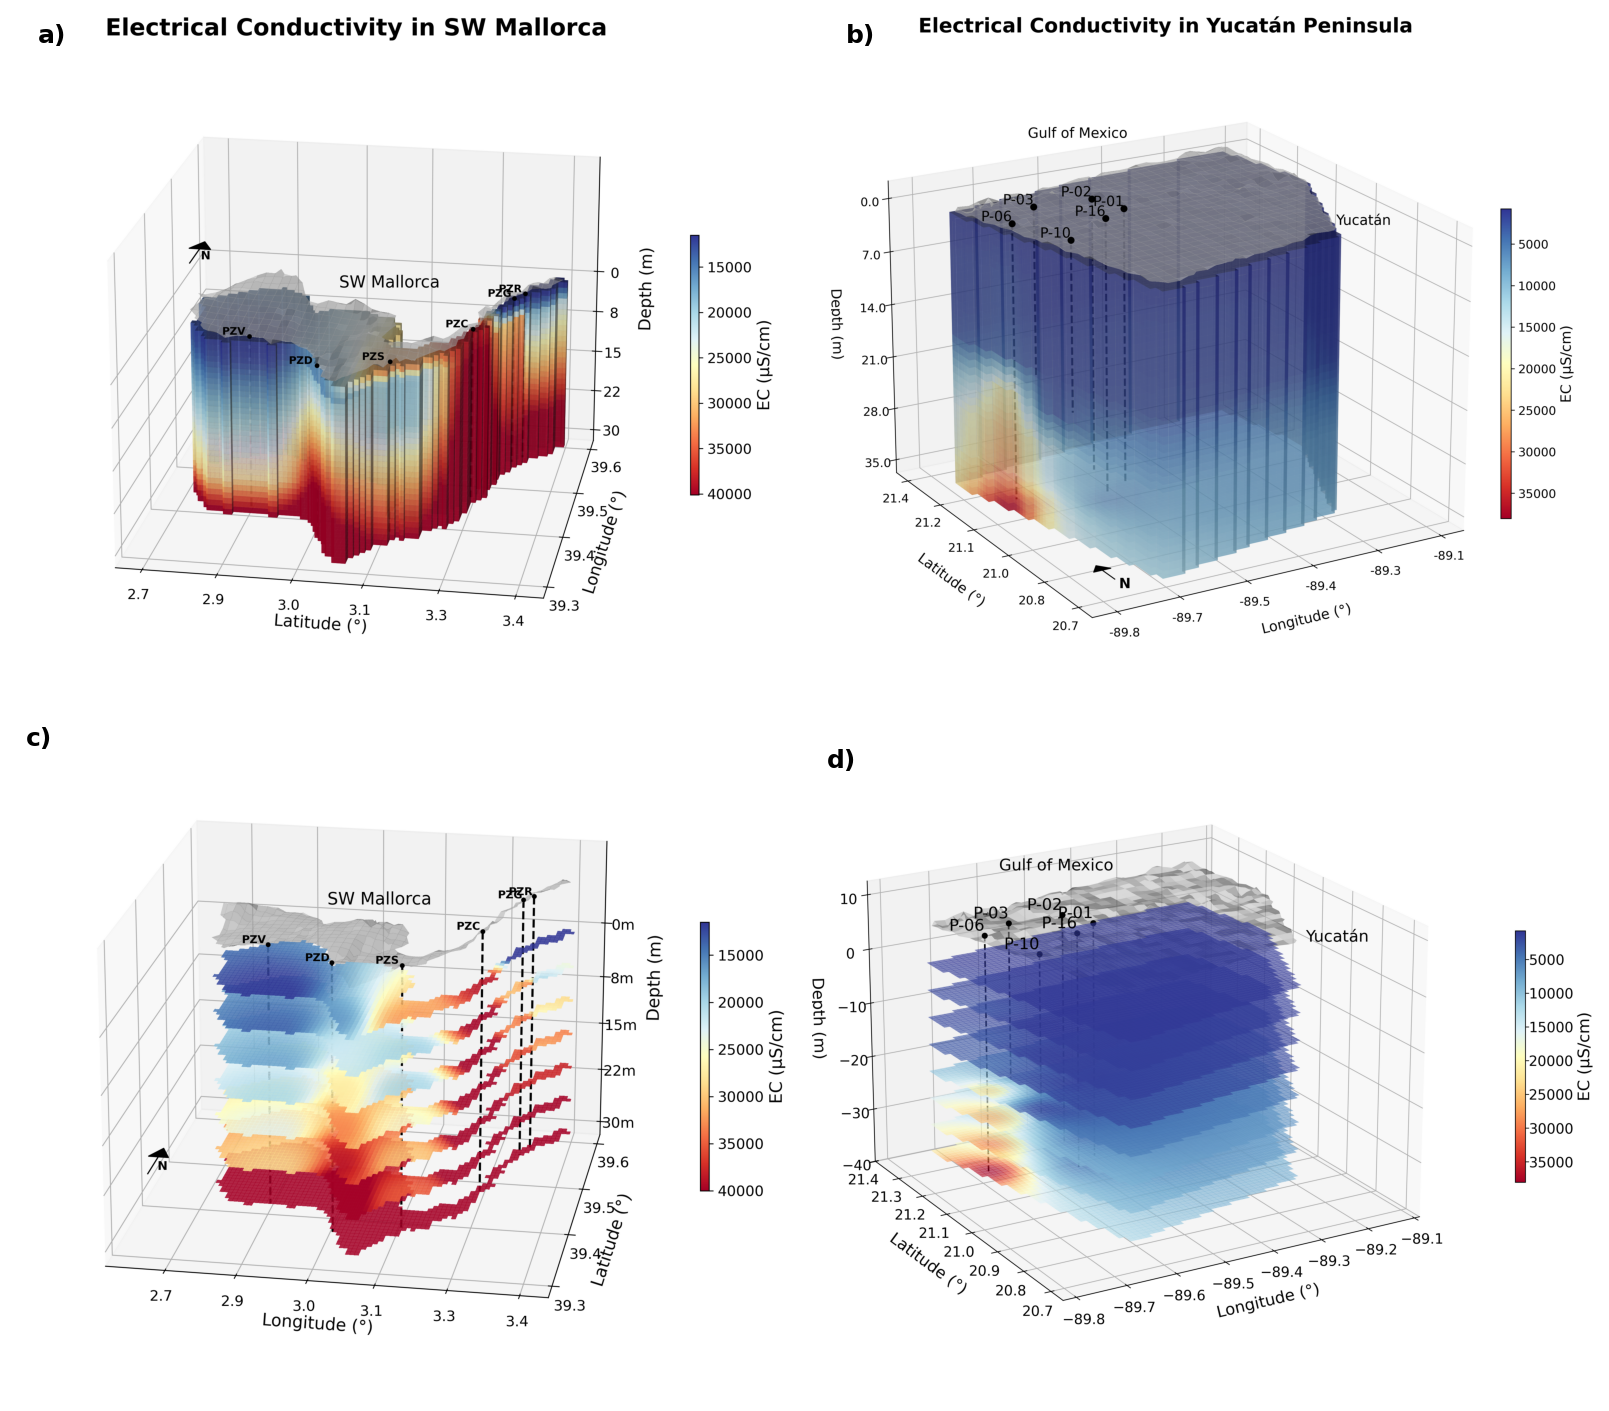

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Cargar imágenes ya generadas
img_3d_m = mpimg.imread("7_3D_M.png")
img_3d_y = mpimg.imread("7_3D_Y.png")
img_capas_m = mpimg.imread("7_capas_M.png")
img_capas_y = mpimg.imread("7_capas_Y.png")

# Crear figura compuesta 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 14), constrained_layout=True)

# Orden: Mallorca izquierda, Yucatán derecha
images = [img_3d_m, img_3d_y, img_capas_m, img_capas_y]
labels = ["a)", "b)", "c)", "d)"]

for ax, img, lab in zip(axes.ravel(), images, labels):
    ax.imshow(img)
    ax.axis("off")
    ax.text(
        0.02, 0.98, lab,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="left"
    )

# Guardar figura final
plt.savefig("7_3D.png", dpi=300, bbox_inches="tight")

# Mostrar en pantalla
plt.show()

/var/folders/f6/wfrnxqf108nbx2nvsph0n70h0000gn/T/ipykernel_37588/1930616255.py:131: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


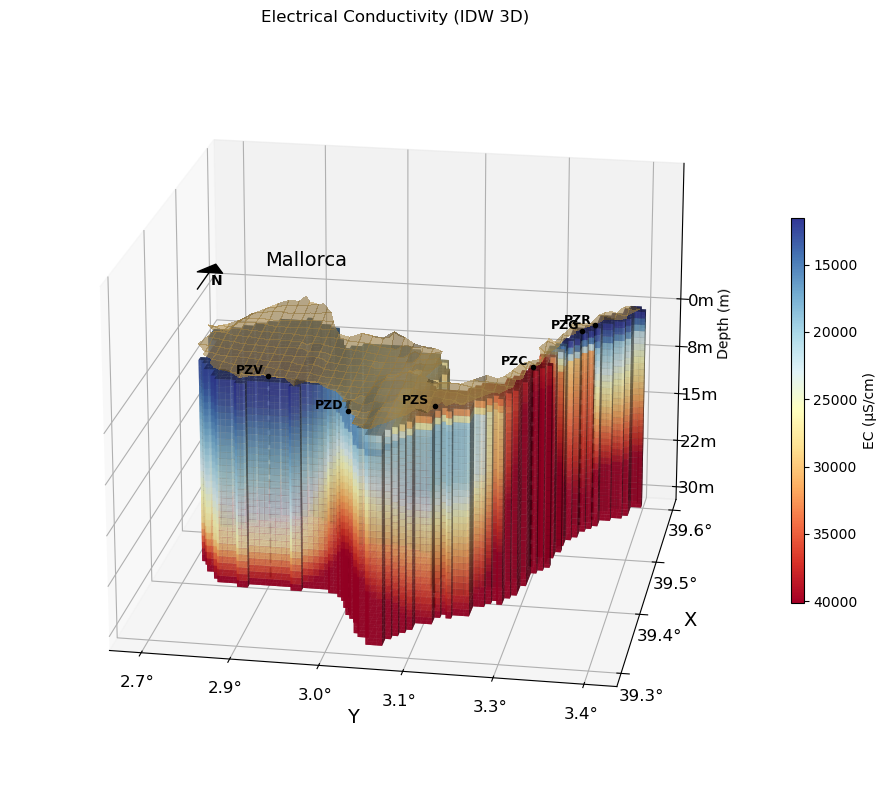

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio as rio
from matplotlib import cm
from shapely import contains_xy
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from pyproj import Transformer  # <-- NUEVO
NX, NZ, V_LIM = 60, 35, (11500, 40000)
DEPTH_TARGETS = np.arange(0, 31, 1)   # 0..30 (31 niveles)
MDT_ZSCALE = -0.02                    # escalado MDT (como antes)
def idw_2d(xy, vals, X, Y, p=3.0, eps=1e-12):
    dx = X.ravel()[:, None] - xy[:, 0]
    dy = Y.ravel()[:, None] - xy[:, 1]
    d = np.sqrt(dx*dx + dy*dy) + eps
    w = 1.0 / (d ** p)
    z = (w @ vals) / w.sum(axis=1)
    return z.reshape(X.shape)
def closest_valid_cell(ix, iy, valid_mask):
    if valid_mask[iy, ix]:
        return ix, iy
    yy, xx = np.argwhere(valid_mask).T
    k = np.argmin((xx - ix)**2 + (yy - iy)**2)
    return int(xx[k]), int(yy[k])
df = pd.read_excel("../datos_M_.xlsx", "3D").dropna(subset=["Well", "x", "y", "Depth_m", "EC"])
df = df.sort_values(["Well", "Depth_m"])
gdf_area = gpd.read_file("../__QGIS/area3.shp").to_crs(epsg=25831)
gdf_pts = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y), crs=4326).to_crs(epsg=25831)
df["E"] = gdf_pts.geometry.x.to_numpy()
df["N"] = gdf_pts.geometry.y.to_numpy()
df["Dpos"] = df["Depth_m"].astype(float)
xmin, ymin, xmax, ymax = gdf_area.total_bounds
nx = 80
ny = int(nx * (ymax - ymin) / (xmax - xmin))
Xg, Yg = np.meshgrid(np.linspace(xmin, xmax, nx),np.linspace(ymin, ymax, ny),indexing="xy")
geom = gdf_area.geometry.union_all()
mask = contains_xy(geom, Xg, Yg)  # (ny,nx)
with rio.open("../__QGIS/mdt_M.tif") as src:
    coords = np.c_[Xg.ravel(), Yg.ravel()]
    S = np.fromiter((v[0] for v in src.sample(coords)), dtype=float, count=coords.shape[0]).reshape(ny, nx)
S = np.where(mask & np.isfinite(S), S, np.nan)
S_norm = S
valid_surface = np.isfinite(S_norm) & mask
well_list = []
for name, g in df.groupby("Well", sort=False):
    d_data = g["Dpos"].to_numpy()
    v_data = g["EC"].to_numpy()
    order = np.argsort(d_data)
    d_data = d_data[order]
    v_data = v_data[order]
    v_interp = np.interp(DEPTH_TARGETS, d_data, v_data, left=v_data[0], right=v_data[-1])
    well_list.append({"name": name,"xy": [g["E"].iloc[0], g["N"].iloc[0]],"vals": v_interp,"dmax": float(d_data.max())})
well_xy = np.array([w["xy"] for w in well_list])           # (n_wells, 2)
well_vals = np.array([w["vals"] for w in well_list])       # (n_wells, 31)
slices = np.empty((len(DEPTH_TARGETS), ny, nx), dtype=float)
for k in range(len(DEPTH_TARGETS)):
    Z = idw_2d(well_xy, well_vals[:, k], Xg, Yg, p=3.0)
    Z[~mask] = np.nan
    slices[k] = Z
cond3d = slices.transpose(2, 1, 0)  # (nx, ny, 31)
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")
filled = np.isfinite(cond3d)
norm = plt.Normalize(11500, 40100)
cmap = cm.RdYlBu_r
colors = cmap(norm(np.nan_to_num(cond3d, nan=11500)))
colors[..., 3] = np.where(filled, 0.8, 0.0)
ax.voxels(filled, facecolors=colors, edgecolor="none")
Xsurf, Ysurf = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")
ax.plot_surface(Xsurf, Ysurf, MDT_ZSCALE * S_norm,color=(0.8, 0.65, 0.35, 0.6), zorder=10,edgecolor="none", linewidth=0, antialiased=False, shade=True)
for w in well_list:
    ex, nn = w["xy"]
    ix = int(np.nanargmin(np.abs(Xg[0, :] - ex)))
    iy = int(np.nanargmin(np.abs(Yg[:, 0] - nn)))
    if not np.isfinite(S_norm[iy, ix]):
        yy, xx = np.argwhere(np.isfinite(S_norm)).T
        k = np.argmin((xx - ix)**2 + (yy - iy)**2)
        ix, iy = int(xx[k]), int(yy[k])
    z_top = MDT_ZSCALE * S_norm[iy, ix]
    d_clamped = np.clip(w["dmax"], DEPTH_TARGETS[0], DEPTH_TARGETS[-1])
    iz_bottom = float(np.interp(d_clamped, DEPTH_TARGETS, np.arange(len(DEPTH_TARGETS))))
    ax.plot([ix, ix], [iy, iy], [z_top, iz_bottom], "--", alpha=1, color="k", lw=2)
    ax.plot([ix], [iy], [z_top], ".", color="k", alpha=1, lw=1, zorder=10000000)
    ax.text(ix-6, iy, z_top, str(w["name"]),fontweight="bold",fontsize=9,color="black", zorder=10000000, clip_on=False)
lab = {"text": "Mallorca", "x_frac": 0.20, "y_frac": 0.85, "z_off": -4, "ha": "center"}
ix = int(lab["x_frac"] * (nx - 1))
iy = int(lab["y_frac"] * (ny - 1))
ix, iy = closest_valid_cell(ix, iy, valid_surface)
z0 = MDT_ZSCALE * S_norm[iy, ix] + lab["z_off"]
ax.text(ix, iy, z0, lab["text"], ha=lab["ha"], va="bottom", fontsize=14, clip_on=False)
anchor = {"x_frac": 0.08, "y_frac": 0.12, "z": -20, "scale": 3.0}
ix_anchor = anchor["x_frac"] * (nx - 1)
iy_anchor = anchor["y_frac"] * (ny - 1)
iz_top = anchor["z"]
s = anchor["scale"]
p1 = (ix_anchor + s*0.5,  iy_anchor,     iz_top)
p2 = (ix_anchor + s*2.0,  iy_anchor,     iz_top)
p3 = (ix_anchor + s*1.25, iy_anchor + s, iz_top)
ax.add_collection3d(Poly3DCollection([[p1, p2, p3]], edgecolor="k", facecolor="k", linewidths=1))
x_mid = ix_anchor + s*1.25
y_end = iy_anchor - s*2.0
ax.plot([x_mid, x_mid], [iy_anchor, y_end], [iz_top, iz_top], color="k", lw=1)
ax.text(x_mid + s*1.01, y_end + s*0.25, iz_top, "N",color="k", fontsize=10, fontweight="bold",ha="center", va="bottom", clip_on=False)
ax.invert_zaxis()
ax.view_init(elev=20, azim=-80)
ax.set_zlabel("Depth (m)")
ax.set_title("Electrical Conductivity (IDW 3D)", pad=2)
z_ticks = np.linspace(0, len(DEPTH_TARGETS)-1, 5)
ax.set_zticks(z_ticks)
ax.set_zticklabels([f"{d:.0f}m" for d in np.linspace(0, DEPTH_TARGETS[-1], 5)], fontsize=12)
transformer = Transformer.from_crs(25831, 4326, always_xy=True)
xticks = np.linspace(0, nx-1, 6).round().astype(int)
yticks = np.linspace(0, ny-1, 4).round().astype(int)
iy_mid = ny // 2
x_e = Xg[iy_mid, xticks]
y_n = Yg[iy_mid, xticks]
lon, lat_dummy = transformer.transform(x_e, y_n)
ix_mid = nx // 2
x_e2 = Xg[yticks, ix_mid]
y_n2 = Yg[yticks, ix_mid]
lon_dummy, lat = transformer.transform(x_e2, y_n2)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{v:.1f}°" for v in lon], fontsize=12)
ax.set_xlabel("Y", fontsize=14)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{v:.1f}°" for v in lat],fontsize=12)
ax.set_ylabel("X", fontsize=14)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = plt.colorbar(sm, ax=ax, pad=0.01, shrink=0.5, aspect=30, label="EC (µS/cm)").ax.invert_yaxis() 
plt.tight_layout()
fig.savefig("6_3D_M.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/f6/wfrnxqf108nbx2nvsph0n70h0000gn/T/ipykernel_37588/1270836494.py:155: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


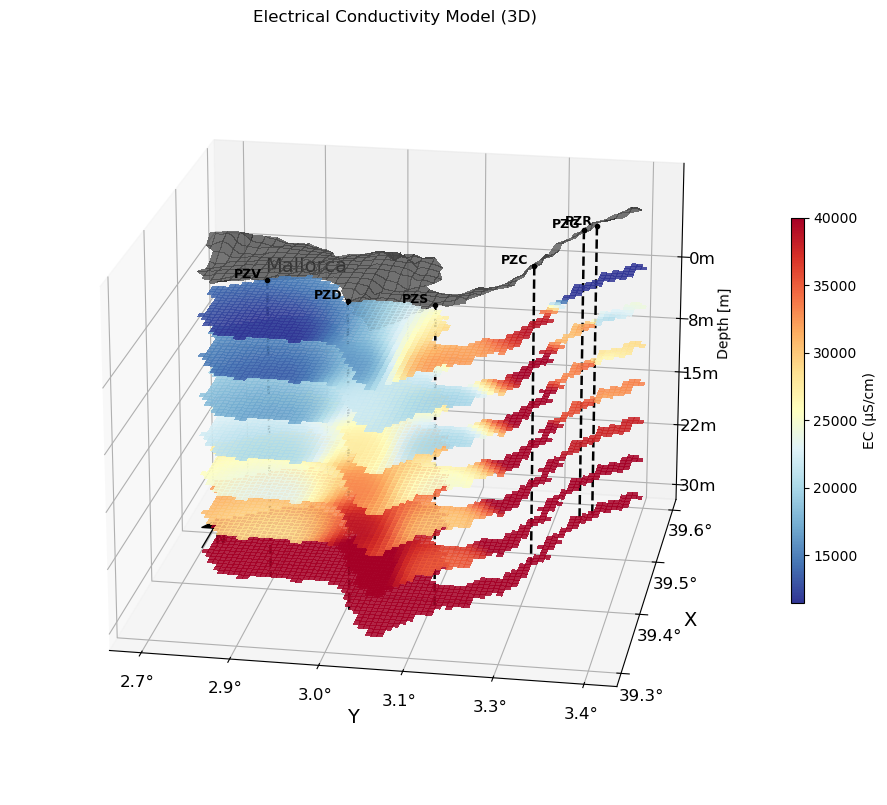

In [13]:
# =========================
# PLOT "EN CAPAS" (SLICES)
# =========================
from matplotlib import cm
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --- Ajustes de capas ---
DEPTHS_TO_PLOT = np.arange(0, 31, 5)   # capas cada 3 m: 0,3,6,...,30
ALPHA_SLICE = 0.85                    # transparencia de cada capa
TOPO_ZSCALE = MDT_ZSCALE              # usas el mismo escalado que ya tenías
TOPO_ZSHIFT = 8.0                     # desplaza MDT hacia arriba para que quede por encima de 0 m

# --- Normalización / colormap ---
norm = plt.Normalize(V_LIM[0], V_LIM[1])
cmap = cm.RdYlBu_r

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Grilla en "índices" como en tu figura de voxels
Xidx, Yidx = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")

# ---- MDT (superficie) ----
# Ojo: S_norm tiene NaNs fuera de la máscara
Ztopo = TOPO_ZSCALE * S_norm + TOPO_ZSHIFT
ax.plot_surface(
    Xidx, Yidx, Ztopo,
    color=(0.35, 0.35, 0.35, 0.75),
    edgecolor="none",
    linewidth=0,
    antialiased=False,
    shade=True,
    zorder=10,
)

# ---- Capas horizontales de EC ----
# slices: (n_depths, ny, nx)
for d in DEPTHS_TO_PLOT:
    k = int(d)  # porque DEPTH_TARGETS = 0..30 paso 1
    plane = slices[k].copy()  # (ny, nx)

    # Colores por celda
    fc = cmap(norm(np.nan_to_num(plane, nan=V_LIM[0])))
    # Alpha 0 fuera de máscara / NaNs
    valid = np.isfinite(plane) & mask
    fc[..., 3] = np.where(valid, ALPHA_SLICE, 0.0)

    # Plano a profundidad -d (como la figura de capas)
    Zplane = -float(d) * np.ones_like(plane)

    ax.plot_surface(
        Xidx, Yidx, Zplane,
        facecolors=fc,
        rcount=ny, ccount=nx,
        shade=False,
        edgecolor="none",
        linewidth=0,
        antialiased=False,
        zorder=1,
    )

# ---- Pozos (líneas verticales + etiqueta) ----
valid_surface = np.isfinite(S_norm) & mask

def closest_valid_cell(ix, iy, valid_mask):
    if valid_mask[iy, ix]:
        return ix, iy
    yy, xx = np.argwhere(valid_mask).T
    k = np.argmin((xx - ix)**2 + (yy - iy)**2)
    return int(xx[k]), int(yy[k])

for w in well_list:
    ex, nn = w["xy"]

    ix = int(np.nanargmin(np.abs(Xg[0, :] - ex)))
    iy = int(np.nanargmin(np.abs(Yg[:, 0] - nn)))
    ix, iy = closest_valid_cell(ix, iy, valid_surface)

    z_top = TOPO_ZSCALE * S_norm[iy, ix] + TOPO_ZSHIFT
    z_bottom = -float(np.clip(w["dmax"], DEPTH_TARGETS[0], DEPTH_TARGETS[-1]))

    ax.plot([ix, ix], [iy, iy], [z_top, z_bottom], "--", color="k", lw=1.8, alpha=1.0)
    ax.plot([ix], [iy], [z_top], ".", color="k", alpha=1.0, zorder=1000)
    ax.text(ix-6, iy, z_top, str(w["name"]), fontweight="bold", fontsize=9, color="black",
            zorder=2000, clip_on=False)

# ---- Etiqueta Mallorca (como antes) ----
lab = {"text": "Mallorca", "x_frac": 0.20, "y_frac": 0.85, "z_off": -4, "ha": "center"}
ix_lab = int(lab["x_frac"] * (nx - 1))
iy_lab = int(lab["y_frac"] * (ny - 1))
ix_lab, iy_lab = closest_valid_cell(ix_lab, iy_lab, valid_surface)
z0 = (TOPO_ZSCALE * S_norm[iy_lab, ix_lab] + TOPO_ZSHIFT) + lab["z_off"]
ax.text(ix_lab, iy_lab, z0, lab["text"], ha=lab["ha"], va="bottom", fontsize=14, clip_on=False)

# ---- Flecha Norte (igual que tu versión) ----
anchor = {"x_frac": 0.08, "y_frac": 0.12, "z": -20, "scale": 3.0}
ix_anchor = anchor["x_frac"] * (nx - 1)
iy_anchor = anchor["y_frac"] * (ny - 1)
iz_top = anchor["z"]
s = anchor["scale"]
p1 = (ix_anchor + s*0.5,  iy_anchor,     iz_top)
p2 = (ix_anchor + s*2.0,  iy_anchor,     iz_top)
p3 = (ix_anchor + s*1.25, iy_anchor + s, iz_top)
ax.add_collection3d(Poly3DCollection([[p1, p2, p3]], edgecolor="k", facecolor="k", linewidths=1))
x_mid = ix_anchor + s*1.25
y_end = iy_anchor - s*2.0
ax.plot([x_mid, x_mid], [iy_anchor, y_end], [iz_top, iz_top], color="k", lw=1)
ax.text(x_mid + s*1.01, y_end + s*0.25, iz_top, "N",
        color="k", fontsize=10, fontweight="bold", ha="center", va="bottom", clip_on=False)

# ---- Vista / ejes ----
ax.view_init(elev=20, azim=-80)

ax.set_title("Electrical Conductivity Model (3D)", pad=2)
ax.set_zlabel("Depth [m]")

# Límites de Z: superficie un poco por encima de 0 y fondo a -30
ax.set_zlim(-DEPTH_TARGETS[-1] - 2, TOPO_ZSHIFT + 4)

# Ticks de profundidad (0 arriba, -30 abajo)
z_ticks = np.array([0, -8, -15, -22, -30], dtype=float)
ax.set_zticks(z_ticks)
ax.set_zticklabels([f"{int(abs(z))}m" for z in z_ticks], fontsize=12)

# ---- Etiquetas en grados como ya hacías ----
from pyproj import Transformer
transformer = Transformer.from_crs(25831, 4326, always_xy=True)

xticks = np.linspace(0, nx-1, 6).round().astype(int)
yticks = np.linspace(0, ny-1, 4).round().astype(int)

iy_mid = ny // 2
x_e = Xg[iy_mid, xticks]
y_n = Yg[iy_mid, xticks]
lon, _ = transformer.transform(x_e, y_n)

ix_mid = nx // 2
x_e2 = Xg[yticks, ix_mid]
y_n2 = Yg[yticks, ix_mid]
_, lat = transformer.transform(x_e2, y_n2)

ax.set_xticks(xticks)
ax.set_xticklabels([f"{v:.1f}°" for v in lon], fontsize=12)
ax.set_xlabel("Y", fontsize=14)

ax.set_yticks(yticks)
ax.set_yticklabels([f"{v:.1f}°" for v in lat], fontsize=12)
ax.set_ylabel("X", fontsize=14)

# ---- Colorbar ----
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = plt.colorbar(sm, ax=ax, pad=0.01, shrink=0.5, aspect=30)
cbar.set_label("EC (µS/cm)")

plt.tight_layout()
fig.savefig("6_capas_M.png", dpi=300, bbox_inches="tight")
plt.show()
